<a href="https://colab.research.google.com/github/harshakurada/PredictX-AI-Predictive-Maintenance/blob/main/main_predictX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install plotly shap xgboost lightgbm -q

In [2]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving ai4i+2020+predictive+maintenance+dataset (1).zip to ai4i+2020+predictive+maintenance+dataset (1).zip


In [6]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"

df = pd.read_csv(url)

In [7]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [8]:
print(df.shape)

(10000, 14)


In [9]:
print("="*50)
print("Dataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

Dataset Shape
(10000, 14)

Columns
Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

Missing Values
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate Rows
0


In [10]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace(" ", "_")
)

df.columns

Index(['udi', 'product_id', 'type', 'air_temperature_k',
       'process_temperature_k', 'rotational_speed_rpm', 'torque_nm',
       'tool_wear_min', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf'],
      dtype='object')

In [11]:
df["temp_difference"] = (
    df["process_temperature_k"]
    - df["air_temperature_k"]
)

df["power_index"] = (
    df["torque_nm"]
    * df["rotational_speed_rpm"]
)

df["wear_torque_interaction"] = (
    df["tool_wear_min"]
    * df["torque_nm"]
)

df["wear_speed_ratio"] = (
    df["tool_wear_min"]
    /
    df["rotational_speed_rpm"]
)

df["health_score"] = (
    100
    -
    (df["tool_wear_min"]/df["tool_wear_min"].max())*50
    -
    (df["torque_nm"]/df["torque_nm"].max())*50
)

In [12]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

total_assets = len(df)
failures = df["machine_failure"].sum()

healthy = total_assets - failures

failure_rate = round(
    failures/total_assets*100,
    2
)

fig = make_subplots(
    rows=1,
    cols=4,
    specs=[[{"type":"indicator"}]*4]
)

metrics = [
    total_assets,
    healthy,
    failures,
    failure_rate
]

titles = [
    "Total Assets",
    "Healthy Assets",
    "Failures",
    "Failure Rate %"
]

for i in range(4):

    fig.add_trace(
        go.Indicator(
            mode="number",
            value=metrics[i],
            title={"text":titles[i]}
        ),
        row=1,
        col=i+1
    )

fig.update_layout(
    height=300
)

fig.show()

In [13]:
import plotly.express as px

failure_type = (
    df.groupby("type")
    ["machine_failure"]
    .mean()
    .reset_index()
)

fig = px.bar(
    failure_type,
    x="type",
    y="machine_failure",
    text_auto=True,
    title="Failure Rate by Machine Type"
)

fig.show()

In [14]:
corr = (
    df.corr(numeric_only=True)
    ["machine_failure"]
    .sort_values()
)

fig = px.bar(
    corr,
    orientation="h",
    title="Failure Driver Ranking"
)

fig.show()

In [15]:
corr = df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=".2f",
    aspect="auto",
    title="Feature Correlation Heatmap"
)

fig.show()

In [16]:
fig = px.scatter_3d(
    df,
    x="tool_wear_min",
    y="torque_nm",
    z="process_temperature_k",
    color="machine_failure",
    size="rotational_speed_rpm",
    opacity=0.7
)

fig.show()

In [17]:
fig = px.density_heatmap(
    df,
    x="tool_wear_min",
    y="torque_nm",
    z="machine_failure",
    title="Failure Risk Zones"
)

fig.show()

In [18]:
df["wear_stage"] = pd.cut(
    df["tool_wear_min"],
    bins=[0,50,100,150,200,250],
    labels=[
        "New",
        "Young",
        "Mid-Life",
        "Aging",
        "Critical"
    ]
)

aging = (
    df.groupby("wear_stage")
    ["machine_failure"]
    .mean()
    .reset_index()
)

fig = px.line(
    aging,
    x="wear_stage",
    y="machine_failure",
    markers=True,
    title="Failure Probability Across Lifecycle"
)

fig.show()

/tmp/ipykernel_4534/2266612927.py:14: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [19]:
cols = [
    "air_temperature_k",
    "process_temperature_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min"
]

fig = px.parallel_coordinates(
    df,
    dimensions=cols,
    color="machine_failure"
)

fig.show()

In [21]:
failure_cols = [
    "twf",
    "hdf",
    "pwf",
    "osf",
    "rnf"
]

failure_counts = (
    df[failure_cols]
    .sum()
    .reset_index()
)

failure_counts.columns = [
    "Failure Type",
    "Count"
]

fig = px.pie(
    failure_counts,
    names="Failure Type",
    values="Count",
    hole=0.5,
    title="Failure Cause Distribution"
)

fig.show()

In [22]:
fig = px.histogram(
    df,
    x="health_score",
    nbins=30,
    color="machine_failure",
    title="Fleet Health Distribution"
)

fig.show()

In [23]:
importance = (
    df.corr(numeric_only=True)
    ["machine_failure"]
    .abs()
    .sort_values(ascending=False)
)

importance.head(10)

,machine_failure
machine_failure,1.000000
hdf,0.575800
osf,0.531083
pwf,0.522812
twf,0.362904
torque_nm,0.191321
wear_torque_interaction,0.190427
health_score,0.181790
power_index,0.176039
wear_speed_ratio,0.130213


In [24]:
# Temperature behavior

df["temp_difference"] = (
    df["process_temperature_k"]
    - df["air_temperature_k"]
)

# Mechanical power approximation

df["power_index"] = (
    df["torque_nm"]
    * df["rotational_speed_rpm"]
)

# Stress indicator

df["wear_torque_interaction"] = (
    df["tool_wear_min"]
    * df["torque_nm"]
)

# Efficiency indicator

df["wear_speed_ratio"] = (
    df["tool_wear_min"]
    /
    df["rotational_speed_rpm"]
)

# Thermal stress

df["thermal_stress"] = (
    df["temp_difference"]
    * df["torque_nm"]
)

# Mechanical stress

df["mechanical_stress"] = (
    df["torque_nm"]
    * df["tool_wear_min"]
)

# Overall health score

df["health_score"] = (
    100
    -
    (df["tool_wear_min"]/df["tool_wear_min"].max())*50
    -
    (df["torque_nm"]/df["torque_nm"].max())*50
)

In [25]:
df["machine_failure"].value_counts()

,count
machine_failure,
0,9661
1,339


In [26]:
failure_pct = (
    df["machine_failure"]
    .value_counts(normalize=True)
    *100
)

print(failure_pct)

machine_failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [27]:
df["type"].unique()


array(['M', 'L', 'H'], dtype=object)

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["type_encoded"] = le.fit_transform(
    df["type"]
)

In [29]:
drop_cols = [
    "udi",
    "product_id",
    "type"
]

df_model = df.drop(
    columns=drop_cols
)


In [37]:
df_model = df.drop(
    columns=[
        "udi",
        "product_id",
        "type",
        "wear_stage"
    ]
)

In [38]:
X = df_model.drop(
    columns=["machine_failure"]
)

y = df_model["machine_failure"]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1]

    metrics = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC_AUC": roc_auc_score(y_test, probabilities)
    }

    return metrics

In [53]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

lr_results = evaluate_model(
    lr,
    X_test_scaled,
    y_test
)

print(lr_results)

{'Accuracy': 0.9685, 'Precision': 0.6190476190476191, 'Recall': 0.19117647058823528, 'F1': 0.29213483146067415, 'ROC_AUC': np.float64(0.9259225429302155)}


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_results = evaluate_model(
    rf,
    X_test,
    y_test
)

print(rf_results)

{'Accuracy': 0.9915, 'Precision': 0.9473684210526315, 'Recall': 0.7941176470588235, 'F1': 0.864, 'ROC_AUC': np.float64(0.9802703690171722)}


In [55]:
!pip install xgboost -q

In [56]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train
)

xgb_results = evaluate_model(
    xgb,
    X_test,
    y_test
)

print(xgb_results)

{'Accuracy': 0.9915, 'Precision': 0.9180327868852459, 'Recall': 0.8235294117647058, 'F1': 0.8682170542635659, 'ROC_AUC': np.float64(0.9847308488612836)}


In [57]:
!pip install lightgbm -q

In [58]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    random_state=42
)

lgbm.fit(
    X_train,
    y_train
)

lgbm_results = evaluate_model(
    lgbm,
    X_test,
    y_test
)

print(lgbm_results)

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2538
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [59]:
results = pd.DataFrame(
    [
        lr_results,
        rf_results,
        xgb_results,
        lgbm_results
    ],
    index=[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ]
)

results

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.9685,0.619048,0.191176,0.292135,0.925923
Random Forest,0.9915,0.947368,0.794118,0.864000,0.980270
XGBoost,0.9915,0.918033,0.823529,0.868217,0.984731
LightGBM,0.9920,0.933333,0.823529,0.875000,0.979075


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [60]:
from sklearn.metrics import confusion_matrix
import plotly.express as px

cm = confusion_matrix(
    y_test,
    xgb.predict(X_test)
)

fig = px.imshow(
    cm,
    text_auto=True,
    labels=dict(
        x="Predicted",
        y="Actual"
    ),
    title="XGBoost Confusion Matrix"
)

fig.show()

In [61]:
from sklearn.metrics import roc_curve
import plotly.graph_objects as go

prob = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    prob
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=fpr,
        y=tpr,
        mode="lines",
        name="XGBoost"
    )
)

fig.update_layout(
    title="ROC Curve",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate"
)

fig.show()

In [62]:
!pip install shap -q

In [63]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

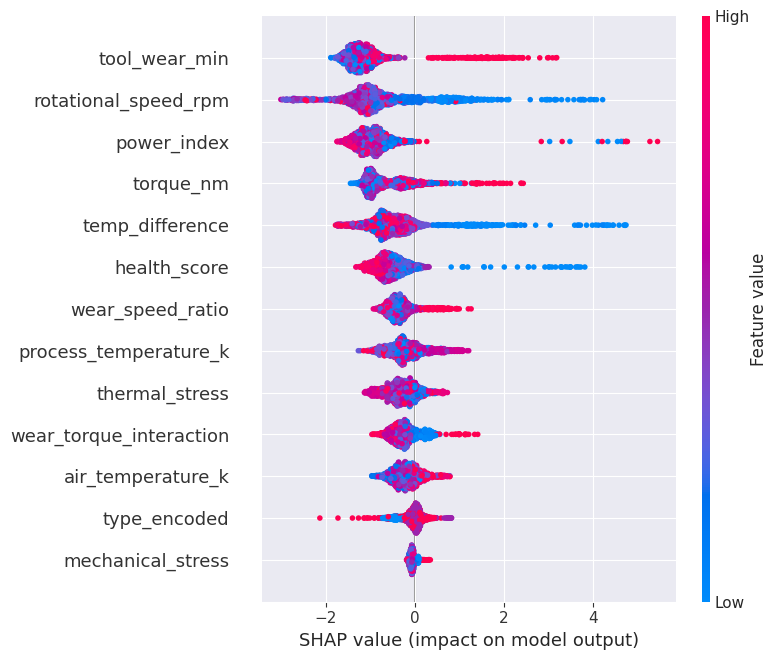

In [64]:
shap.summary_plot(
    shap_values,
    X_test
)

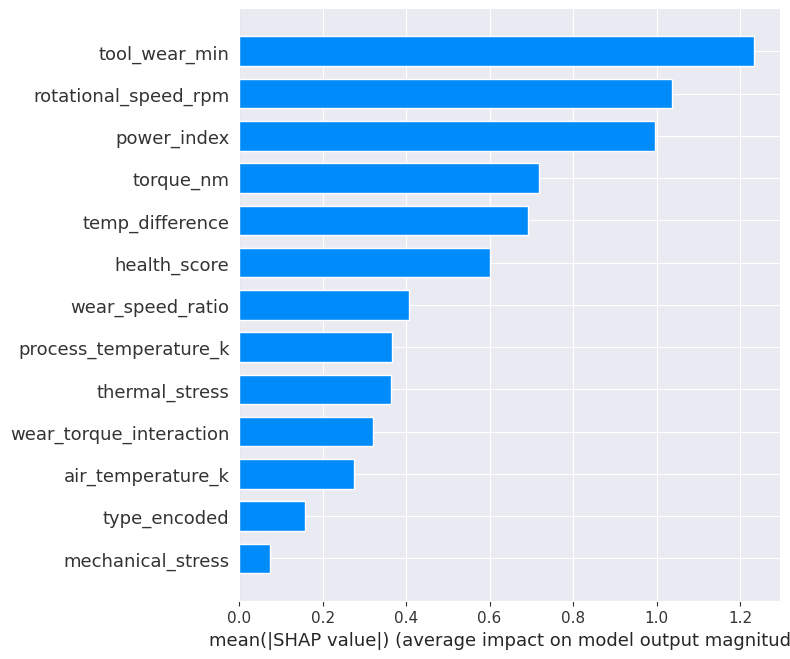

In [65]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [68]:
def predict_failure(
    air_temp,
    process_temp,
    rpm,
    torque,
    tool_wear,
    machine_type
):

    temp_difference = process_temp - air_temp

    power_index = torque * rpm

    wear_torque_interaction = tool_wear * torque

    wear_speed_ratio = tool_wear / rpm

    health_score = (
        100
        - (tool_wear/250)*50
        - (torque/80)*50
    )

    thermal_stress = (
        temp_difference * torque
    )

    mechanical_stress = (
        torque * tool_wear
    )

    row = pd.DataFrame({
        "air_temperature_k":[air_temp],
        "process_temperature_k":[process_temp],
        "rotational_speed_rpm":[rpm],
        "torque_nm":[torque],
        "tool_wear_min":[tool_wear],
        "temp_difference":[temp_difference],
        "power_index":[power_index],
        "wear_torque_interaction":[wear_torque_interaction],
        "wear_speed_ratio":[wear_speed_ratio],
        "health_score":[health_score],
        "thermal_stress":[thermal_stress],
        "mechanical_stress":[mechanical_stress],
        "type_encoded":[machine_type]
    })

    probability = xgb.predict_proba(row)[0][1]

    return probability

In [69]:
risk = predict_failure(
    air_temp=300,
    process_temp=310,
    rpm=1500,
    torque=40,
    tool_wear=100,
    machine_type=1
)

print(
    f"Failure Probability: {risk:.2%}"
)

Failure Probability: 0.00%


In [70]:
health_score = (
    100 - risk*100
)

print(
    f"Health Score: {health_score:.1f}/100"
)

Health Score: 100.0/100


In [71]:
def risk_category(risk):

    if risk < 0.2:
        return "Healthy"

    elif risk < 0.5:
        return "Warning"

    elif risk < 0.8:
        return "High Risk"

    else:
        return "Critical"

In [72]:
baseline = predict_failure(
    300,
    310,
    1500,
    40,
    100,
    1
)

In [73]:
scenario = predict_failure(
    300,
    310,
    1500,
    55,
    100,
    1
)

In [74]:
print(
    f"Current Risk : {baseline:.2%}"
)

print(
    f"New Risk : {scenario:.2%}"
)

print(
    f"Change : {(scenario-baseline):.2%}"
)

Current Risk : 0.00%
New Risk : 0.02%
Change : 0.02%


In [75]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=["Current"],
        y=[baseline*100]
    )
)

fig.add_trace(
    go.Bar(
        x=["What-If"],
        y=[scenario*100]
    )
)

fig.update_layout(
    title="Risk Comparison"
)

fig.show()

In [76]:
def recommend(
    torque,
    tool_wear,
    risk
):

    recommendations=[]

    if tool_wear > 180:
        recommendations.append(
            "Replace cutting tool"
        )

    if torque > 60:
        recommendations.append(
            "Inspect motor assembly"
        )

    if risk > 0.8:
        recommendations.append(
            "Schedule immediate maintenance"
        )

    return recommendations

In [77]:
recommend(
    torque=70,
    tool_wear=220,
    risk=0.89
)

['Replace cutting tool',
 'Inspect motor assembly',
 'Schedule immediate maintenance']

In [78]:
import numpy as np
import pandas as pd

fleet_size = 500

fleet = pd.DataFrame({
    "Machine_ID":[f"M{i:04d}" for i in range(fleet_size)],

    "air_temperature_k":
        np.random.normal(300,2,fleet_size),

    "process_temperature_k":
        np.random.normal(310,2,fleet_size),

    "rotational_speed_rpm":
        np.random.randint(1100,1800,fleet_size),

    "torque_nm":
        np.random.randint(20,80,fleet_size),

    "tool_wear_min":
        np.random.randint(0,250,fleet_size),

    "type_encoded":
        np.random.randint(0,3,fleet_size)
})

In [79]:
fleet["temp_difference"] = (
    fleet["process_temperature_k"]
    - fleet["air_temperature_k"]
)

fleet["power_index"] = (
    fleet["torque_nm"]
    * fleet["rotational_speed_rpm"]
)

fleet["wear_torque_interaction"] = (
    fleet["tool_wear_min"]
    * fleet["torque_nm"]
)

fleet["wear_speed_ratio"] = (
    fleet["tool_wear_min"]
    /
    fleet["rotational_speed_rpm"]
)

fleet["health_score"] = (
    100
    -
    (fleet["tool_wear_min"]/250)*50
    -
    (fleet["torque_nm"]/80)*50
)

fleet["thermal_stress"] = (
    fleet["temp_difference"]
    * fleet["torque_nm"]
)

fleet["mechanical_stress"] = (
    fleet["tool_wear_min"]
    * fleet["torque_nm"]
)

In [80]:
feature_cols = X.columns

fleet["failure_probability"] = (
    xgb.predict_proba(
        fleet[feature_cols]
    )[:,1]
)

In [81]:
def asset_status(prob):

    if prob < 0.20:
        return "Healthy"

    elif prob < 0.50:
        return "Warning"

    elif prob < 0.80:
        return "High Risk"

    else:
        return "Critical"

In [82]:
fleet["status"] = (
    fleet["failure_probability"]
    .apply(asset_status)
)

In [83]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

healthy = (
    fleet["status"]=="Healthy"
).sum()

warning = (
    fleet["status"]=="Warning"
).sum()

critical = (
    fleet["status"]=="Critical"
).sum()

avg_risk = (
    fleet["failure_probability"]
    .mean()*100
)

In [84]:
fig = make_subplots(
    rows=1,
    cols=4,
    specs=[[{"type":"indicator"}]*4]
)

metrics = [
    len(fleet),
    healthy,
    critical,
    avg_risk
]

titles = [
    "Total Assets",
    "Healthy Assets",
    "Critical Assets",
    "Average Risk %"
]

for i in range(4):

    fig.add_trace(
        go.Indicator(
            mode="number",
            value=metrics[i],
            title={"text":titles[i]}
        ),
        row=1,
        col=i+1
    )

fig.show()

In [85]:
import plotly.express as px

fig = px.histogram(
    fleet,
    x="failure_probability",
    color="status",
    nbins=40,
    title="Fleet Risk Distribution"
)

fig.show()

In [87]:
top20 = (
    fleet
    .sort_values(
        "failure_probability",
        ascending=False
    )
    .head(20)
)
fig = px.bar(
    top20,
    x="Machine_ID",
    y="failure_probability",
    color="status",
    title="Top 20 High-Risk Assets"
)

fig.show()

In [88]:
maintenance_queue = (
    fleet[
        fleet["failure_probability"] > 0.80
    ]
    .sort_values(
        "failure_probability",
        ascending=False
    )
)

maintenance_queue.head(10)

,Machine_ID,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,type_encoded,temp_difference,power_index,wear_torque_interaction,wear_speed_ratio,health_score,thermal_stress,mechanical_stress,failure_probability,status
422,M0422,303.215252,312.324667,1289,76,225,1,9.109415,97964,17100,0.174554,7.500,692.315568,17100,0.999318,Critical
6,M0006,301.865066,309.971471,1323,62,236,1,8.106405,82026,14632,0.178382,14.050,502.597123,14632,0.999271,Critical
461,M0461,300.649367,311.458859,1337,77,191,1,10.809493,102949,14707,0.142857,13.675,832.330941,14707,0.998939,Critical
83,M0083,299.868312,306.826993,1194,78,44,2,6.958681,93132,3432,0.036851,42.450,542.777115,3432,0.998838,Critical
52,M0052,300.659562,309.164556,1229,72,182,1,8.504994,88488,13104,0.148088,18.600,612.359578,13104,0.998783,Critical
388,M0388,301.920590,310.361985,1439,75,239,1,8.441394,107925,17925,0.166088,5.325,633.104556,17925,0.998671,Critical
45,M0045,304.559489,310.984959,1370,68,239,0,6.425470,93160,16252,0.174453,9.700,436.931928,16252,0.998468,Critical
302,M0302,299.860795,312.689265,1522,70,228,1,12.828469,106540,15960,0.149803,10.650,897.992860,15960,0.997665,Critical
386,M0386,298.660178,308.067908,1666,63,247,1,9.407730,104958,15561,0.148259,11.225,592.686991,15561,0.997447,Critical
448,M0448,299.638731,308.264153,1457,64,229,1,8.625422,93248,14656,0.157172,14.200,552.027034,14656,0.997382,Critical


In [89]:
def estimate_rul(
    tool_wear,
    failure_probability,
    health_score
):

    wear_factor = (
        250 - tool_wear
    ) / 250

    risk_factor = (
        1 - failure_probability
    )

    health_factor = (
        health_score / 100
    )

    rul_days = (
        wear_factor
        * risk_factor
        * health_factor
        * 180
    )

    return round(
        max(rul_days,1),
        1
    )

In [90]:
fleet["rul_days"] = fleet.apply(
    lambda row:
        estimate_rul(
            row["tool_wear_min"],
            row["failure_probability"],
            row["health_score"]
        ),
    axis=1
)

In [91]:
def maintenance_priority(days):

    if days < 7:
        return "Immediate"

    elif days < 30:
        return "Urgent"

    elif days < 60:
        return "Scheduled"

    else:
        return "Normal"

In [93]:
fleet["maintenance_priority"] = (
    fleet["rul_days"]
    .apply(
        maintenance_priority
    )
)

fleet[
    [
        "Machine_ID",
        "failure_probability",
        "rul_days",
        "maintenance_priority"
    ]
].sort_values(
    "rul_days"
).head(20)

,Machine_ID,failure_probability,rul_days,maintenance_priority
21,M0021,0.934594,1.0,Immediate
20,M0020,0.993353,1.0,Immediate
477,M0477,0.762153,1.0,Immediate
470,M0470,0.974920,1.0,Immediate
463,M0463,0.942660,1.0,Immediate
466,M0466,0.979139,1.0,Immediate
461,M0461,0.998939,1.0,Immediate
454,M0454,0.961260,1.0,Immediate
37,M0037,0.996570,1.0,Immediate
45,M0045,0.998468,1.0,Immediate


In [94]:
import plotly.express as px

fig = px.histogram(
    fleet,
    x="rul_days",
    color="maintenance_priority",
    nbins=40,
    title="Remaining Useful Life Distribution"
)

fig.show()

In [95]:
top20_rul = (
    fleet
    .sort_values(
        "rul_days"
    )
    .head(20)
)

fig = px.bar(
    top20_rul,
    x="Machine_ID",
    y="rul_days",
    color="maintenance_priority",
    title="Assets Requiring Immediate Attention"
)

fig.show()

In [96]:
fig = px.scatter(
    fleet,
    x="failure_probability",
    y="rul_days",
    color="maintenance_priority",
    size="tool_wear_min",
    hover_data=["Machine_ID"],
    title="Failure Risk vs Remaining Useful Life"
)

fig.show()

In [97]:
fig = px.scatter(
    fleet,
    x="tool_wear_min",
    y="failure_probability",
    color="maintenance_priority",
    size="rul_days",
    hover_data=["Machine_ID"],
    title="Maintenance Planning Matrix"
)

fig.show()

In [98]:
from datetime import datetime, timedelta

fleet["recommended_maintenance_date"] = (
    pd.to_datetime(
        datetime.today()
    )
    +
    pd.to_timedelta(
        fleet["rul_days"],
        unit="D"
    )
)

In [99]:
maintenance_center = fleet[
    [
        "Machine_ID",
        "failure_probability",
        "health_score",
        "rul_days",
        "maintenance_priority",
        "recommended_maintenance_date"
    ]
]

maintenance_center.sort_values(
    "rul_days"
).head(20)

,Machine_ID,failure_probability,health_score,rul_days,maintenance_priority,recommended_maintenance_date
21,M0021,0.934594,17.275,1.0,Immediate,2026-06-24 13:41:49.404400
20,M0020,0.993353,21.125,1.0,Immediate,2026-06-24 13:41:49.404400
477,M0477,0.762153,19.000,1.0,Immediate,2026-06-24 13:41:49.404400
470,M0470,0.974920,4.075,1.0,Immediate,2026-06-24 13:41:49.404400
463,M0463,0.942660,9.325,1.0,Immediate,2026-06-24 13:41:49.404400
466,M0466,0.979139,37.425,1.0,Immediate,2026-06-24 13:41:49.404400
461,M0461,0.998939,13.675,1.0,Immediate,2026-06-24 13:41:49.404400
454,M0454,0.961260,18.675,1.0,Immediate,2026-06-24 13:41:49.404400
37,M0037,0.996570,4.025,1.0,Immediate,2026-06-24 13:41:49.404400
45,M0045,0.998468,9.700,1.0,Immediate,2026-06-24 13:41:49.404400


In [100]:
import joblib

joblib.dump(xgb, "predictx_best_model.pkl")

['predictx_best_model.pkl']

In [101]:
fleet.to_csv(
    "fleet_data.csv",
    index=False
)